In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Ensure visualizations display correctly inline in the notebook
%matplotlib inline

In [2]:
# Load the dataset
df = pd.read_csv('..\datasets\iris.csv')

# Display the dataset structure
display(df.head())
print("\nDataset Info:")
df.info()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [3]:
# Separate features (X) and target (y)
X = df.drop(columns=['species'])
y = df['species']

# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 120 samples
Testing set size: 30 samples


In [4]:
scaler = StandardScaler()

# Fit only on training data, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame just for visualization purposes in the notebook
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
print("Scaled Training Features:")
display(X_train_scaled_df.head())

Scaled Training Features:


,sepal_length,sepal_width,petal_length,petal_width
0,-1.721568,-0.324840,-1.347036,-1.320168
1,-1.124492,-1.226129,0.414290,0.651867
2,1.144395,-0.550162,0.584741,0.257460
3,-1.124492,0.125805,-1.290219,-1.451638
4,-0.408002,-1.226129,0.130206,0.125991


In [5]:
k_values = range(1, 21)
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    # Record accuracy for both sets
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

# Identify the optimal K
best_k = k_values[np.argmax(test_accuracies)]
print(f"Optimal number of neighbors (K) selected: {best_k}")

Optimal number of neighbors (K) selected: 1


In [6]:
# Train final model with best K
best_knn = KNeighborsClassifier(n_neighbors=best_k)
best_knn.fit(X_train_scaled, y_train)
y_pred = best_knn.predict(X_test_scaled)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred))
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.91      1.00      0.95        10
   virginica       1.00      0.90      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Final Test Accuracy: 0.9667


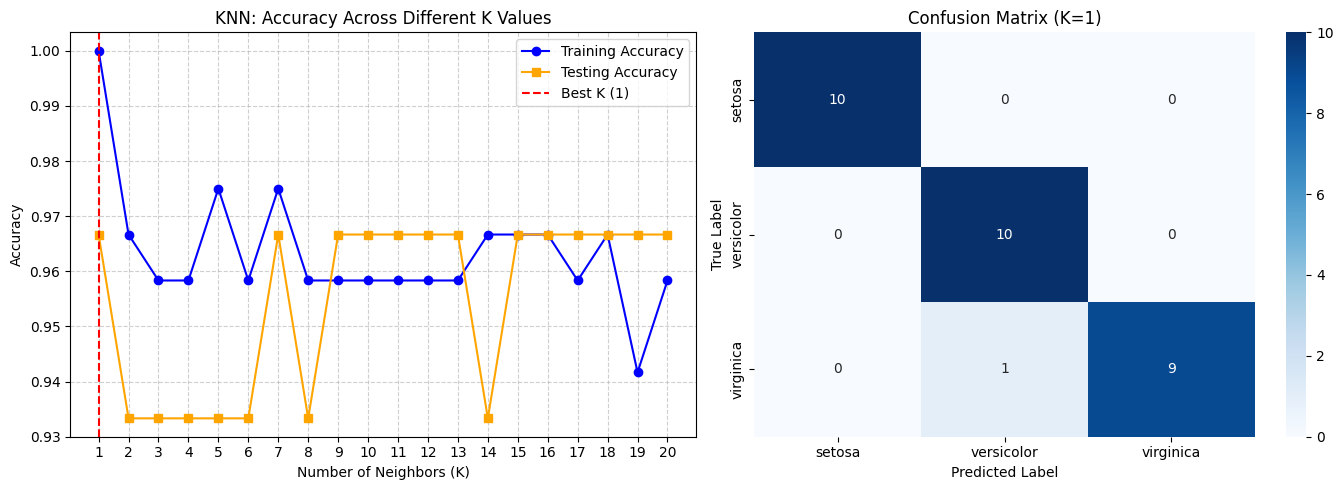

In [7]:
plt.figure(figsize=(14, 5))

# Plot 1: K-Value vs. Accuracy
plt.subplot(1, 2, 1)
plt.plot(k_values, train_accuracies, label='Training Accuracy', marker='o', color='blue')
plt.plot(k_values, test_accuracies, label='Testing Accuracy', marker='s', color='orange')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K ({best_k})')
plt.title('KNN: Accuracy Across Different K Values')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Confusion Matrix Heatmap
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
classes = np.unique(y) 
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title(f'Confusion Matrix (K={best_k})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.tight_layout()
plt.show()